## This notebook shows the distribution of # data points in galaxies

In [105]:
from astropy.table import Table

import numpy as np

import matplotlib.pyplot as plt

from tqdm import tqdm

### Cut 1
10764 galaxies

In [9]:
loa1 = Table.read('/pscratch/sd/d/dbustos/rot_curves/loa_targs.fits')
loa1[:5]

TARGETID,SGA_ID,TARGET_RA,TARGET_DEC,Z,Z_ERR,ZWARN,DELTACHI2,DIST,DIST_R26,PA,C_TO_F_ANGLE,ANGLE_OFF_AXIS,Selection,ZERR_MOD,unique_obs,Velocity,V_err,Z_center
int64,int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64
1084427169955849,556089,242.72318746350186,53.635782093163655,0.03063192091855999,0.03063192091855999,0,789.0584922824055,0.0017610627660455075,0.32999999905624167,44.0717658996582,224.0717662682332,0.0,1,0.030631930371296624,3.0,42.73534606638948,12955.934441406864,0.030485035010313136
1084434300272644,375898,243.65642926326169,54.27724177905015,0.07850942434688926,0.07850942434688926,0,310.9083716990426,0.0018719092656299759,0.32999999823339154,54.93254852294922,54.93254783937784,0.0,1,0.07850942838567453,3.0,-186.32208858017614,40998.983929035065,0.11197763201881784
1084427178344451,21266,243.62537013307835,53.712014537285526,0.05723634298805001,0.05723634298805001,0,849.3460895419121,0.0015670324751866896,0.32999999454262413,111.70044708251953,111.70044970679623,0.0,1,0.05723634831154621,3.0,190.61562929764193,29488.240413800784,0.07999449571015632
1084434300272643,375898,243.65118121249577,54.275090804072406,0.07974131508417623,0.07974131508417623,0,1123.4490712519037,0.001871909265610506,0.3299999982299592,54.93254852294922,234.93254783934097,0.0,1,0.07974131906965695,3.0,155.89283818049722,41212.106251148354,0.11197763201881784
1084427178344450,21266,243.62044993111272,53.713173370492754,0.05591772316967483,0.05591772316967483,0,2463.962895900011,0.0015670324751904594,0.329999994543418,111.70044708251953,291.700449706759,0.0,1,0.05591772860512272,3.0,-183.53309221409478,29259.976909073113,0.07999449571015632


In [110]:
# find number of unique observations

x1 = np.empty(len(np.unique(loa1['SGA_ID'])))

for j, i in tqdm(enumerate(np.unique(loa1['SGA_ID']))):
    
    fiber = loa1['SGA_ID'] == i 

    obs = loa1[fiber]

    # identify all points on semimajor axis
    on_major = obs[obs['ANGLE_OFF_AXIS'] == 0]
    if len(on_major) == 0:
        unique_on = 0

    else:
        on_major['DIST_R26'] = np.round(on_major['DIST_R26'], 6)
        on_major = on_major.group_by('DIST_R26')
        unique_on = len(on_major.groups)

    # identify all points off major axis
    off_major = obs[obs['ANGLE_OFF_AXIS'] != 0]
    
    # find number of unique points off axis
    num_off_major = len(off_major)

    if num_off_major == 0:
        unique_off = 0
    else:
        off_major = off_major.group_by(['DIST_R26','ANGLE_OFF_AXIS'])
        unique_off = len(off_major.groups)

    total_obs = unique_on + unique_off

    x1[j] = total_obs

10764it [00:34, 307.64it/s]


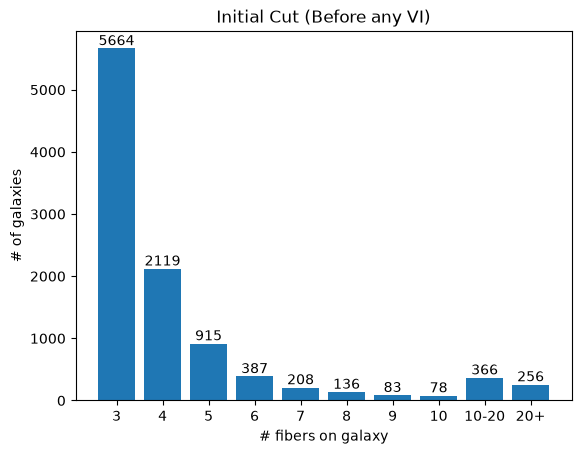

In [127]:
x_vals = ['3', '4', '5', '6', '7', '8', '9', '10', '10-20', '20+']
y_vals = [
    len(x1[x1==3]), len(x1[x1==4]), len(x1[x1==5]), 
    len(x1[x1==6]), len(x1[x1==7]), len(x1[x1==8]), 
    len(x1[x1==9]), len(x1[x1==10]), len(x1[(10<x1)&(x1<20)]), 
    len(x1[x1>20])]

fig, ax = plt.subplots()

bars = ax.bar(x_vals,y_vals)
ax.bar_label(bars)

ax.set_title('Initial Cut (Before any VI)')
ax.set_xlabel('# fibers on galaxy')
ax.set_ylabel('# of galaxies')

fig.show()

fig.savefig('/pscratch/sd/d/dbustos/Histograms/initial_cut', dpi=120)

# Final Cut
3112 galaxies

In [114]:
loa2 = Table.read('/pscratch/sd/d/dbustos/rot_curves/loa_rotvel_curvefit.fits')
loa2[:5]

TARGETID,SGA_ID,TARGET_RA,TARGET_DEC,Z,Z_RR,ZWARN,DELTACHI2,DIST,DIST_R26,PA,C_TO_F_ANGLE,ANGLE_OFF_AXIS,Selection,ZERR_MOD,unique_obs,Velocity,V_err,Z_center,VI,deproj_dist,deproj_r26,manual_VI,rot_vel_filing,r_kpc,chi2_reduced,vmax_fit,rturn_fit,vmax_err,rturn_err
int64,int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64
169678387281926,1430874,257.7495971,56.9324928,0.028921517883227336,0.028921517883227336,0,121857.89663615823,0.003250448915035935,0.31250071154567677,6.557606220245361,206.22810010342067,199.6704938831753,1,2.4024789259983957e-05,3.0,182.8750198451699,11.489101308260244,2.401212431981059e-05,0,0.008096415535868652,0.7783957484224773,0,0,0.20122416188287864,0.38706405138543304,188.0016333989227,0.004035780336833629,145.11961827963177,4.09983872988525
243323033878571,631434,151.0147419137485,1.6331543609904198,1.3809988331159857,1.3809988331159857,4,0.7242707014083862,0.0057124407591539585,0.9175586924842383,51.69132614135742,32.48938717521324,19.201938966144183,1,5.5595100500533275e-05,8.0,472239.65646196203,24.11477245431036,1.7258340278094598e-05,0,0.006601088916040368,1.0602974753074295,0,0,0.26035704174416274,--,--,--,145.11961827963177,4.09983872988525
1004815400304641,188925,193.6701,28.93758,0.0082724267277799,0.0082724267277799,0,20781.262633197082,0.0009923137447555642,0.026284859154548004,48.5860481262207,146.26021571620655,97.67416758998584,2,2.3542643581428787e-05,31.0,-181.63274387448345,72.81809787647651,1.6648346838273807e-05,0,0.0011151277859353821,0.02953801350383857,0,0,0.008088028889852567,5.63436883524322,170.25925589571688,0.03525810913705583,145.11961827963177,4.09983872988525
1005093910478848,1309576,234.30175,43.3014166667,0.019607169071382585,0.019607169071382585,0,21025.242969959974,0.004020441905483598,0.2179634595949638,134.6117401123047,320.7967839323471,186.18504382004244,1,2.380730399661915e-05,8.0,173.70559603525007,12.904304444072334,2.3796769180937358e-05,0,0.005374691904048404,0.2913825069989467,0,0,0.08955195966842268,1.3727806283237154,171.17940047936136,0.040082806353557265,145.11961827963177,4.09983872988525
1005093910478849,1309576,234.303916667,43.2961944444,0.0190429075748926,0.0190429075748926,0,37842.76546475291,0.0023170693385198464,0.12561714881549862,134.6117401123047,204.59833750241611,69.98659739011143,1,2.3794128780331918e-05,8.0,-126.47090634603123,37.70665102866408,2.3796769180937358e-05,0,0.0031473131687750006,0.1706278271946506,0,0,0.05243985459735577,1.3727806283237154,171.17940047936136,0.040082806353557265,145.11961827963177,4.09983872988525


In [115]:
# find number of unique observations

x2 = np.empty(len(np.unique(loa2['SGA_ID'])))

for j, i in tqdm(enumerate(np.unique(loa2['SGA_ID']))):
    
    fiber = loa2['SGA_ID'] == i 

    obs = loa2[fiber]

    # identify all points on semimajor axis
    on_major = obs[obs['ANGLE_OFF_AXIS'] == 0]
    if len(on_major) == 0:
        unique_on = 0

    else:
        on_major['DIST_R26'] = np.round(on_major['DIST_R26'], 6)
        on_major = on_major.group_by('DIST_R26')
        unique_on = len(on_major.groups)

    # identify all points off major axis
    off_major = obs[obs['ANGLE_OFF_AXIS'] != 0]
    
    # find number of unique points off axis
    num_off_major = len(off_major)

    if num_off_major == 0:
        unique_off = 0
    else:
        off_major = off_major.group_by(['DIST_R26','ANGLE_OFF_AXIS'])
        unique_off = len(off_major.groups)

    total_obs = unique_on + unique_off

    x2[j] = total_obs

3112it [00:17, 179.81it/s]


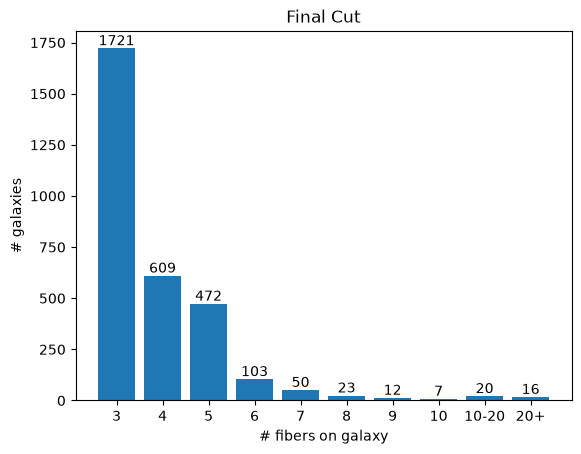

In [126]:
x2_vals = ['3', '4', '5', '6', '7', '8', '9', '10', '10-20', '20+']
y2_vals = [
    len(x2[x2==3]), len(x2[x2==4]), len(x2[x2==5]), 
    len(x2[x2==6]), len(x2[x2==7]), len(x2[x2==8]), 
    len(x2[x2==9]), len(x2[x2==10]), len(x2[(10<x2)&(x2<20)]), 
    len(x2[x2>20])]

fig, ax = plt.subplots()

bars = ax.bar(x2_vals,y2_vals)
ax.bar_label(bars)

ax.set_title('Final Cut')
ax.set_xlabel('# fibers on galaxy')
ax.set_ylabel('# galaxies')

fig.show()

fig.savefig('/pscratch/sd/d/dbustos/Histograms/final_cut', dpi=120)

(array([1.721e+03, 6.090e+02, 4.720e+02, 1.030e+02, 5.000e+01, 2.300e+01,
        1.200e+01, 7.000e+00, 4.000e+00, 2.000e+00, 2.000e+00, 2.000e+00,
        1.000e+00, 4.000e+00, 3.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        2.000e+00, 2.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        2.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

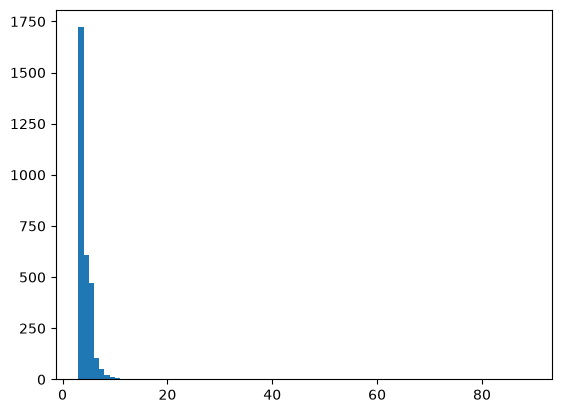

In [134]:
plt.hist(x2, np.arange(3,90,1))

(array([1.721e+03, 6.090e+02, 4.720e+02, 1.030e+02, 5.000e+01, 2.300e+01,
        1.200e+01, 7.000e+00, 4.000e+00, 2.000e+00, 2.000e+00, 2.000e+00,
        1.000e+00, 4.000e+00, 3.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        2.000e+00, 2.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        2.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

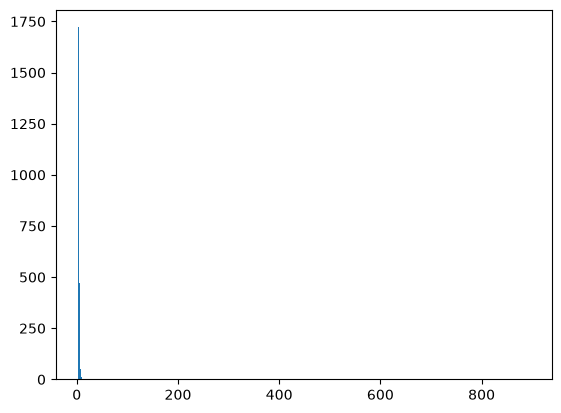

In [141]:
plt.hist(x2, np.arange(3,895,1))